# Access LSST alert data for solar system objects via BigQuery

The Pitt-Google Alert Broker's tabular alert and value-added data is stored in [BigQuery](https://docs.cloud.google.com/bigquery/docs/introduction). The dataset and tables names containing LSST data are outlined in our [data listings page](https://mwvgroup.github.io/pittgoogle-client/listings.html#id4).

## Table of Contents

- [Obtain available photometry of solar system objects](#obtain-photometry-ssobjects)
- [Plot multi-band light curves](#plot-light-curves)

## Prerequisites

- Complete the [One-Time Setup](https://mwvgroup.github.io/pittgoogle-client/one-time-setup/index.html), specifically:
     - Install the pittgoogle-client package
     - Setup authentication to a Google Cloud project
     - Set environment variables
     - Enable the BigQuery API
     - You can skip the command-line tools

In [1]:
import pittgoogle
import matplotlib.pyplot as plt

<a id="obtain-photometry-ssobjects"></a>

## Obtain available photometry of solar system objects

In [2]:
bqclient = pittgoogle.bigquery.Client() # load the BigQuery client

sql_query = f"""
SELECT
  diaSource.psfFlux,
  diaSource.psfFluxErr,
  ssSource.ssObjectId,
  diaSource.band,
  diaSource.midpointMjdTai,
  diaSource.reliability
FROM `pitt-alert-broker.lsst.alerts_v10_0`
WHERE ssSource.ssObjectId IS NOT NULL
ORDER BY ssSource.ssObjectId
LIMIT 500000
"""

results = bqclient.query(query=sql_query)
results

,psfFlux,psfFluxErr,ssObjectId,band,midpointMjdTai,reliability
0,2.976278e+06,1530.571411,20883257468923986,g,61094.202976,1.0
1,2.230440e+06,1336.490601,20883257468923986,g,61095.177689,1.0
2,2.244726e+06,1334.656982,20883257468923986,g,61095.174878,1.0
3,2.460053e+06,1356.580200,20883257468923986,g,61096.360880,1.0
4,2.117726e+06,1276.990601,20883257468923986,g,61095.179563,1.0
...,...,...,...,...,...,...
456327,3.910857e+04,444.854034,23700330444239416,r,61106.243842,1.0
456328,4.483961e+04,1612.426514,23700330444239416,y,61106.246213,1.0
456329,4.396079e+04,1664.488037,23700330444239416,y,61106.245744,1.0
456330,4.728994e+04,526.182800,23700330444239416,z,61106.248142,1.0


The number of unique solar system objects returned by this query is printed by executing the cell below.

In [3]:
len(results["ssObjectId"].unique())

1990

<a id="plot-light-curves"></a>

# Plot multi-band light curves for each ssObject

In [4]:
def plot_lc(ssObjectId, ssObjects):
    photometry = ssObjects[ssObjects.ssObjectId == ssObjectId]

    fig, ax = plt.subplots(figsize=(10, 5))

    for b in photometry.band.unique():
        idx = photometry.band == b
        ax.errorbar(
            photometry.loc[idx].midpointMjdTai,
            photometry.loc[idx].psfFlux,
            yerr=photometry.loc[idx].psfFluxErr,
            fmt='o',
            label=b
        )

    ax.set_xlabel('midpointMjdTai')
    ax.set_ylabel('psfFlux [nJy]')
    ax.set_title(f'Light Curve — ssObjectId {ssObjectId}')
    ax.legend(title='Band')
    plt.tight_layout()
    plt.show()

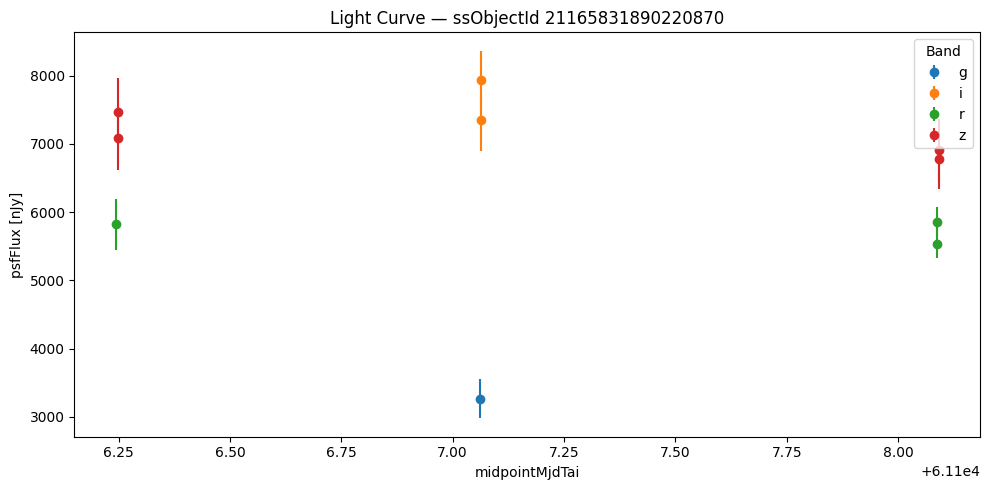

In [5]:
plot_lc(21165831890220870, results)

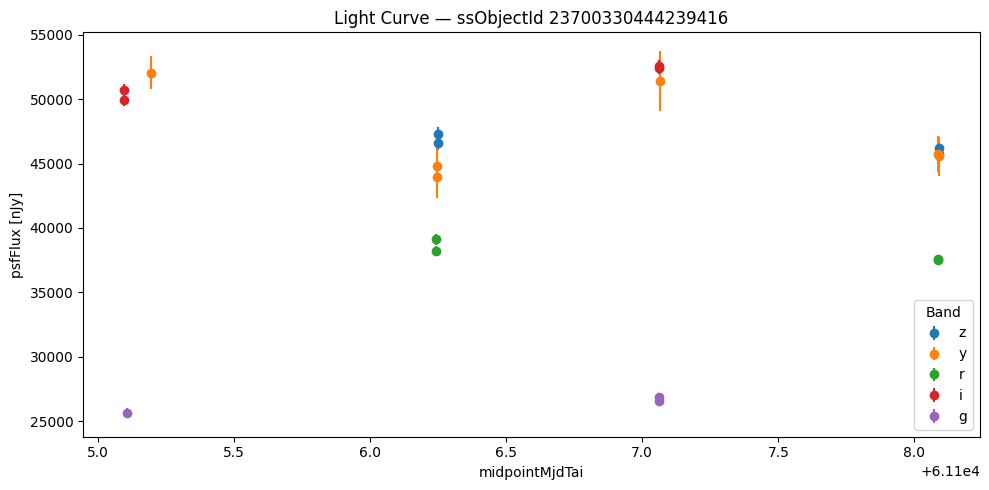

In [6]:
plot_lc(results.ssObjectId.iloc[456327], results)

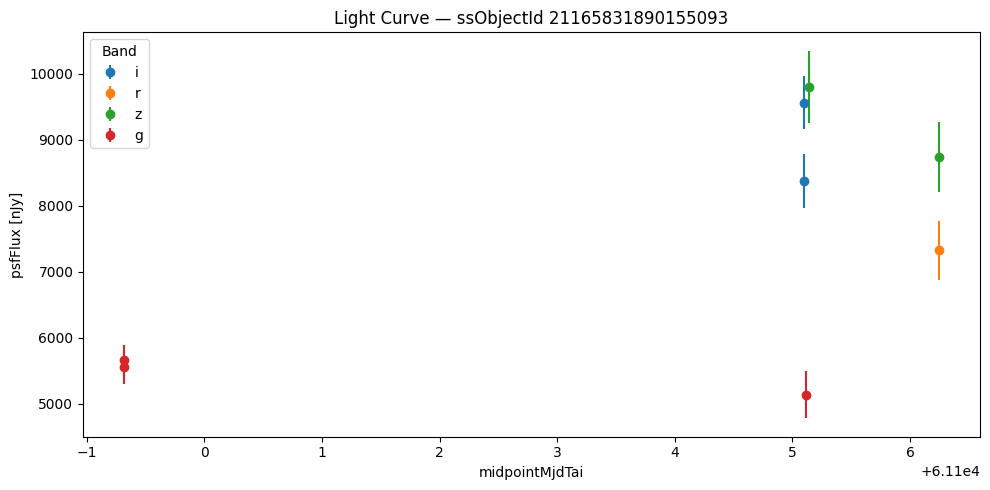

In [7]:
plot_lc(21165831890155093, results)